In [1]:
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.decomposition import PCA

plt.rcParams['figure.dpi'] = 300
sns.set_style('whitegrid')
sns.set_context('notebook')

In [18]:
# load data
DATA_PATH = "data/train_adata.h5ad"
adata = ad.read_h5ad(DATA_PATH)
adata.layers['exprs_arcsinh'] = adata.layers['exprs'] # already arcsinh(x/5)
adata.obsm['spatial'] = adata.obs[['Pos_X', 'Pos_Y']].values

## Task 1

In [3]:
# Prepare dataframe
tumor_fraction = (adata.obs['celltypes'] == 'Tumor').mean()

data = {
    "Metric": [
        "Total Cells", "Total Markers", "Total Images", "Total Indications"
    ] + list(adata.obs["celltypes"].unique()) + ["Tumor Fraction"],
    
    "Value": [
        adata.n_obs, adata.n_vars, adata.obs['image'].nunique(), 
        adata.obs['Indication'].nunique()
    ] + list(adata.obs['celltypes'].value_counts().values) + [round(tumor_fraction, 1)]
}
table_df = pd.DataFrame(data)

In [4]:
table_df

,Metric,Value
0,Total Cells,253433.0
1,Total Markers,40.0
2,Total Images,132.0
3,Total Indications,5.0
4,MacCD163,138266.0
5,Mural,22722.0
6,DC,20537.0
7,Tumor,15288.0
8,CD4,13238.0
9,HLADR,7872.0


## Task 4

For the criterion i've used CD8/Tumor cell ratio. I also limit images to those that have more Tumor cells than CD8 cells.

In [5]:
min_tumor = 500
results=[]

for image in adata.obs["image"].unique():

    cell_counts = adata[adata.obs["image"]==image].obs["celltypes"].value_counts()

    if "CD8" not in cell_counts or "Tumor" not in cell_counts:
        continue

    cd8_count = cell_counts["CD8"]
    tumor_count = cell_counts["Tumor"]

    # filtering out small tumor sized images and images where most of cells are CD8 cells.
    if tumor_count < 1000 or cd8_count > tumor_count:
        continue

    criterion = np.round(cd8_count/tumor_count, 2)

    results.append({"image": image, "criterion_value": criterion})

df = pd.DataFrame(results)
df = df.sort_values(by="criterion_value", ascending=False)
df.head(1)

,image,criterion_value
56,IMMUcan_Batch20220609_S-220218-00008_003.tiff,0.83


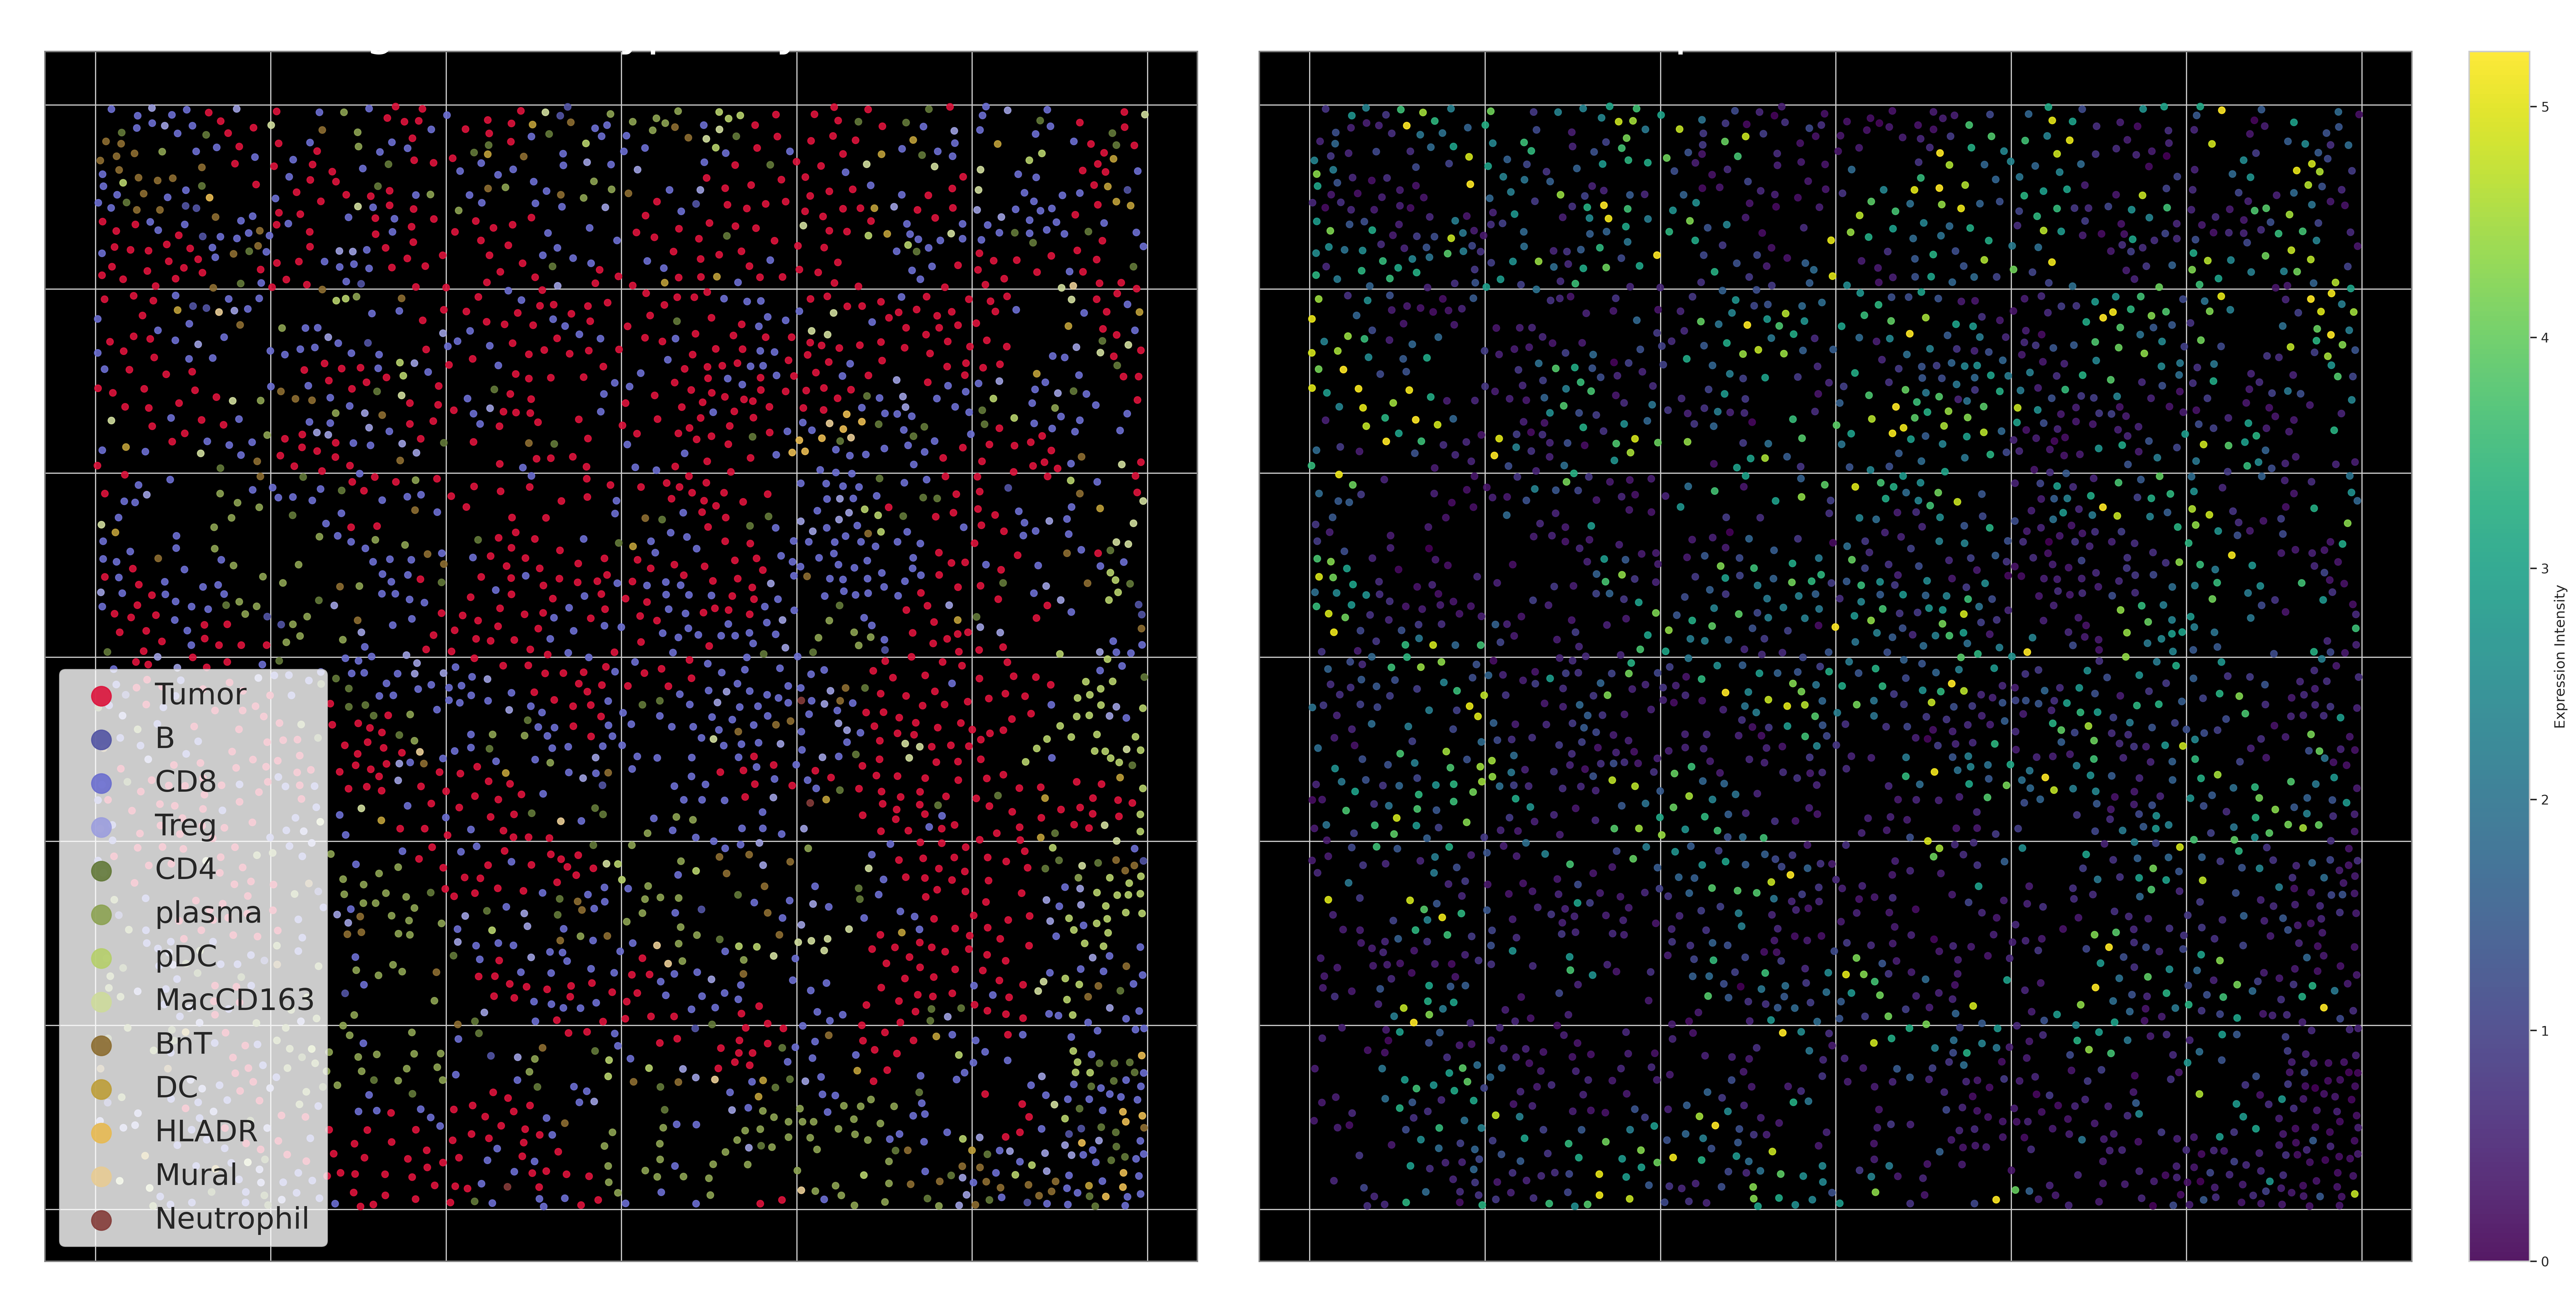

In [ ]:
IMAGE_ID = df.head(1)["image"].values[0]
adata_img = adata[adata.obs["image"] == IMAGE_ID].copy()
coords = adata_img.obsm["spatial"]
marker_to_map = "Ki67"

# create two axes
fig, axes = plt.subplots(1, 2, figsize=(30, 15), constrained_layout=True)

# black background for better visualization
for ax in axes:
    ax.set_facecolor('black')
    ax.set_title(ax.get_title(), color='white', fontsize=40)
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('grey')

ax1 = axes[0]

# Choose unique celltypes and colors for it.
celltypes = adata_img.obs["celltypes"].unique()

# color palette
cmap = plt.get_cmap("tab20b")
color_dict = {
    ct: cmap(i) 
    for i, ct in enumerate(celltypes)
}

# Make sure tumor is different and vivid color.
color_dict["Tumor"] = "crimson"

# color each celltype
for ct in celltypes:
    m = adata_img.obs['celltypes'] == ct
    ax1.scatter(coords[m, 0], coords[m, 1], s=30,
                 alpha=0.9, color=color_dict[ct], label=ct)

ax1.set_title("Image of cell-types by colour", fontsize=40)
ax1.invert_yaxis()
ax1.legend(markerscale=3, fontsize=25)

# right plot
ax2 = axes[1]

# color each cell by it's expression of selected marker
m_idx = np.where(adata_img.var['marker'] == marker_to_map)[0]
marker_expr = adata_img.layers['exprs_arcsinh'][:, m_idx[0]]
sc = ax2.scatter(
            coords[:, 0], coords[:, 1],
            c=marker_expr, cmap='viridis',
            s=30, alpha=0.9, rasterized=True,
            vmin=0, vmax=np.percentile(marker_expr, 99)
        )

ax2.set_title(f"Expression of Ki67", fontsize=40)
ax2.invert_yaxis()
plt.colorbar(sc, ax=ax2, label='Expression Intensity')
plt.show()

Możemy zauważyć, że ekspresja naszego markeru "Ki67" całkiem sensownie odróżnia komórki nowotworowe od innych typów (widać w tych samych miejscach co "tumor" cell zwiększoną ekspresję), wiec tak sygnał tego markera pozostaje zgodny z granicami typów komórkowych, aczkolwiek są miejsca gdzie radzi sobie on gorzej i zwiększonej ekspresji nie widać mimo, że komórka jest oznaczona jako nowotworowa.